# Práctica guiada: aprendizaje no supervisado con Wine Clustering

En esta práctica vas a aplicar técnicas de **aprendizaje no supervisado** al dataset `wine-clustering.csv`.

## Objetivos
- Explorar un conjunto de datos sin etiquetas.
- Preparar los datos correctamente.
- Aplicar **K-Means** con distintos valores de `k`.
- Utilizar el **método del codo** y el **silhouette score**.
- Interpretar los clusters obtenidos.

> Completa las celdas y responde a las cuestiones planteadas.


## 1. Carga del dataset

Carga el archivo CSV en un DataFrame llamado `df` y muestra las primeras filas.


In [144]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# Escribe aquí tu código
df = pd.read_csv("wine-clustering.csv")
df.head()

,Alcohol,Malic_Acid,Ash,Ash_Alcanity,Magnesium,Total_Phenols,Flavanoids,Nonflavanoid_Phenols,Proanthocyanins,Color_Intensity,Hue,OD280,Proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


## 2. Primer análisis del dataset

Obtén:
- número de filas y columnas;
- tipos de datos;
- estadísticos descriptivos.

### Cuestión
¿Todas las variables son numéricas? ¿Hay diferencias importantes de escala entre unas columnas y otras?

En base a lo que vemos en información, podemos ver que hay 178 filas, con todo variables numéricas. Si hay diferencias de escala entre las distintas variables, porque la variable Proline por ejemplo, es mucho mayor que el resto (hablando numericamente).


In [145]:
# Escribe aquí tu código
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Alcohol               178 non-null    float64
 1   Malic_Acid            178 non-null    float64
 2   Ash                   178 non-null    float64
 3   Ash_Alcanity          178 non-null    float64
 4   Magnesium             178 non-null    int64  
 5   Total_Phenols         178 non-null    float64
 6   Flavanoids            178 non-null    float64
 7   Nonflavanoid_Phenols  178 non-null    float64
 8   Proanthocyanins       178 non-null    float64
 9   Color_Intensity       178 non-null    float64
 10  Hue                   178 non-null    float64
 11  OD280                 178 non-null    float64
 12  Proline               178 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 18.2 KB


In [146]:
df.corr()["Alcohol"].sort_values(ascending=False)

Alcohol                 1.000000
Proline                 0.643720
Color_Intensity         0.546364
Total_Phenols           0.289101
Magnesium               0.270798
Flavanoids              0.236815
Ash                     0.211545
Proanthocyanins         0.136698
Malic_Acid              0.094397
OD280                   0.072343
Hue                    -0.071747
Nonflavanoid_Phenols   -0.155929
Ash_Alcanity           -0.310235
Name: Alcohol, dtype: float64

## 3. Preprocesamiento

Aplica un escalado con `StandardScaler`.

### Cuestión
¿Por qué es importante escalar los datos antes de aplicar K-Means?

Porque si no normalizamos los datos, el modelo de KMeans le dará mas pero a ciertas variables que a otras simplemente por el número

In [147]:
from sklearn.preprocessing import StandardScaler

# Crea una variable X con las columnas del dataset
# Después escala los datos y guarda el resultado en X_scaled
# En este problema voy a busccar grupos de vinos, segun el alcohol que tengan
X = df

escalador = StandardScaler()
X = escalador.fit_transform(X)

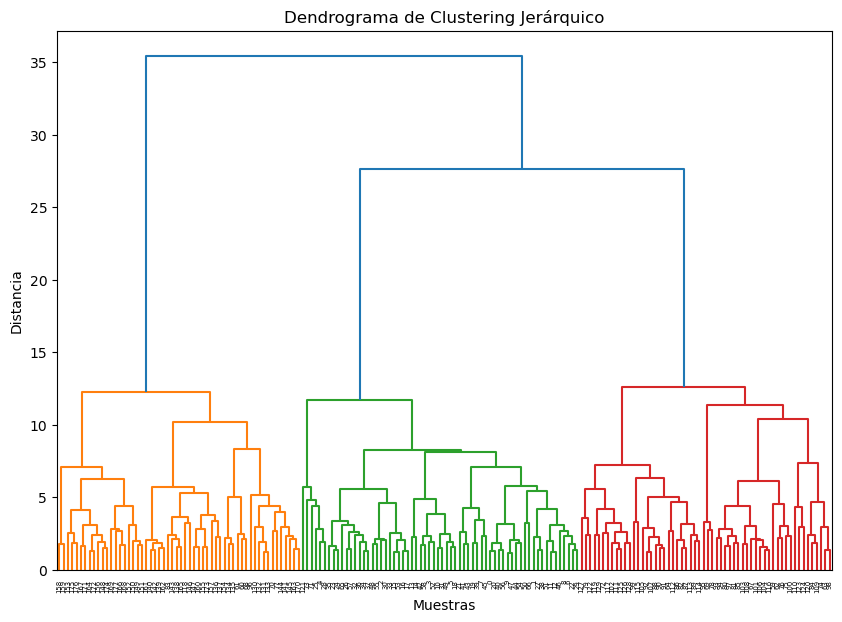

In [148]:
# Para poder ver tambien los grupos, podremos hacer un dendrograma
Z = linkage(X, method="ward")
plt.figure(figsize=(10, 7,))
dendrogram(Z, p=3)
plt.title("Dendrograma de Clustering Jerárquico")
plt.xlabel("Muestras")
plt.ylabel("Distancia")
plt.show()

## 4. Prueba distintos valores de k

Calcula la **inercia** y el **silhouette score** para valores de `k` entre 2 y 10.


In [149]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inercias = []
silhouettes = []
valores_k = range(2, 11)

# Completa el bucle
for k in valores_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inercias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, kmeans.labels_))

## 5. Representa el método del codo

Haz una gráfica de `k` frente a `inercia`.

### Cuestión
¿En qué valor de `k` parece producirse el “codo”?


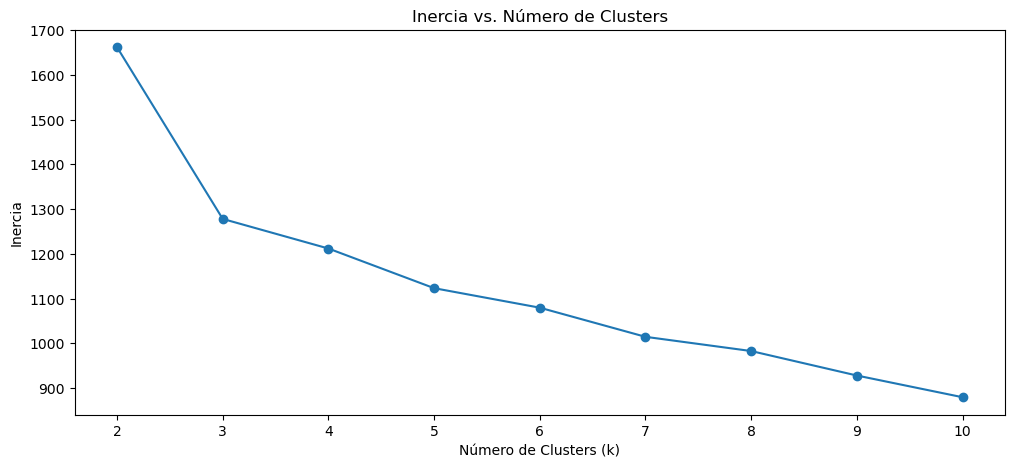

In [150]:
import matplotlib.pyplot as plt

# Escribe aquí tu código
plt.figure(figsize=(12, 5))
plt.plot(valores_k, inercias, marker="o")
plt.title("Inercia vs. Número de Clusters")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Inercia")
plt.show()

## 6. Representa el silhouette score

Haz una gráfica de `k` frente a `silhouette`.

### Cuestión
¿Qué valor de `k` obtiene el mejor resultado?
Para ver el mejor valor de K, hemos usado el metodo del codo, en el cual en la representación gráfica ha salido 3, lo cual esta bien ya que en el dendrograma salen 3 distintos clústers

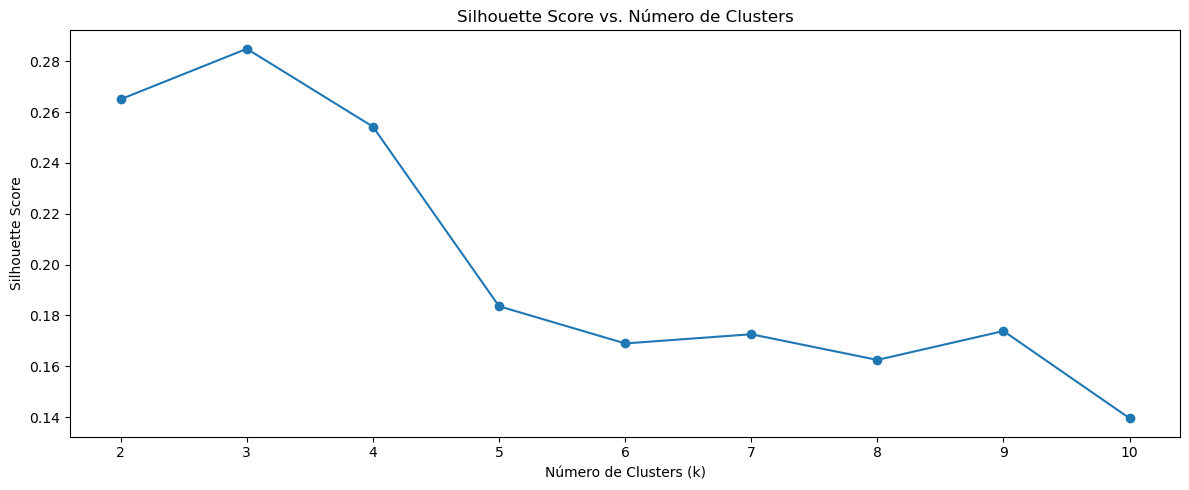

In [ ]:
# Representando el valor de silhouette vs el número de clusters
plt.figure(figsize=(12, 5))
plt.plot(valores_k, silhouettes, marker="o")
plt.title("Silhouette Score vs. Número de Clusters")
plt.xlabel("Número de Clusters (k)")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()

## 7. Entrena el modelo final

Elige el valor de `k` que consideres más adecuado y entrena un modelo final de K-Means.

Guarda las etiquetas de cluster en una nueva columna llamada `cluster`.

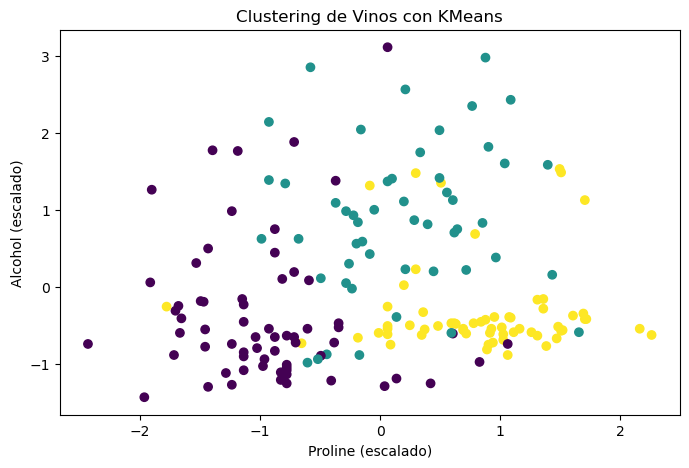

In [152]:
# Escribe aquí tu código
# Entrenando el modelo con el número optimo de clusters
k_optimo = 3
kmeans_optimo = KMeans(n_clusters=k_optimo, random_state=42)
labels_optimo = kmeans_optimo.fit_predict(X)
plt.figure(figsize=(8, 5))
plt.scatter(X[:, 0], X[:, 1], c=labels_optimo, cmap="viridis")
plt.title("Clustering de Vinos con KMeans")
plt.xlabel("Proline (escalado)")
plt.ylabel("Alcohol (escalado)")
plt.show()

## 8. Evalúa el modelo

Calcula el **silhouette score** del modelo final.

### Cuestión
¿Te parece un resultado bueno, aceptable o bajo? Razona tu respuesta.

El resultado de 0.45 no es un resultado óptimo, pero es decente y en base al dendrograma y al 

In [153]:
# Calculando el silhouette score para el modelo con k=3
silhouette_k3 = silhouette_score(X, labels_optimo)
print(f"Silhouette Score para k=3: {silhouette_k3:.4f}")

Silhouette Score para k=3: 0.2849


## 9. Analiza el tamaño de los clusters

Cuenta cuántos registros hay en cada cluster.


In [154]:
# Escribe aquí tu código
# Vamos a ver cuantos registros hay en cada cluster
import numpy as np
unique, counts = np.unique(labels_optimo, return_counts=True)
print("Número de muestras en cada cluster:")
for cluster, count in zip(unique, counts):
    print(f"Cluster {cluster}: {count} muestras")

Número de muestras en cada cluster:
Cluster 0: 65 muestras
Cluster 1: 51 muestras
Cluster 2: 62 muestras


## 10. Interpreta los clusters

Calcula la media de cada variable por cluster.

### Cuestiones
1. ¿Qué variables parecen diferenciar más unos clusters de otros?
    - Las variables que mas diferencian unos clusters de otros, en base al alcohol son Proline y Color Intensity. Esto se debe a que al hacer la correlación, son las variables con mayor peso o influencia tienen.
2. ¿Qué perfil de vino podría representar cada grupo?
    - El Cluster 0 es aquel, cuyo vino tiene poca graduación y poco proline.
    - El Cluster 1, es representado por una graduación media y un nivel de proline medio
    - El Cluster 2, es aquel cuya graduación de alcohol es muy alta al igual que el nivel de proline.


In [156]:
# Escribe aquí tu código
# Calcula la media de cada variable para cada cluster
df_clusters = pd.DataFrame(X, columns=df.columns)
df_clusters["Cluster"] = labels_optimo
medias_por_cluster = df_clusters.groupby("Cluster").mean()
print("Media de cada variable por cluster:")
print(medias_por_cluster)

Media de cada variable por cluster:
          Alcohol  Malic_Acid       Ash  Ash_Alcanity  Magnesium  \
Cluster                                                            
0       -0.926072   -0.394042 -0.494517      0.170602  -0.491712   
1        0.164907    0.871547  0.186898      0.524367  -0.075473   
2        0.835232   -0.303810  0.364706     -0.610191   0.577587   

         Total_Phenols  Flavanoids  Nonflavanoid_Phenols  Proanthocyanins  \
Cluster                                                                     
0            -0.075983    0.020813             -0.033534         0.058266   
1            -0.979330   -1.215248              0.726064        -0.779706   
2             0.885237    0.977820             -0.562090         0.580287   

         Color_Intensity       Hue     OD280   Proline  
Cluster                                                 
0              -0.901914  0.461804  0.270764 -0.753846  
1               0.941539 -1.164789 -1.292412 -0.407088  
2        

## 11. Reflexión final

Responde brevemente:

1. ¿En qué se diferencia el aprendizaje supervisado del no supervisado?
    - El aprendizaje no supervisado es aquel que en sus datos no hayamos etiquetas con la finalidad de encontrar patrones. Aparte, la finalidad del supervisado, es usar datos etiquetados para poder predecir una variable objetivo
2. ¿Por qué K-Means no siempre encuentra la mejor solución posible?
    - No siempre encuentra la mejor solución, porque empieza eligiendo los centroides al azar, puede quedarse en minimos locales.
3. ¿Qué papel juega el preprocesamiento en este problema?
    - El preprocesamiento es clave porque garantiza que todas las variables tengan un peso adecuado. En caso de no normalizar los datos, unas variables tendrían mas peso que otras.
4. ¿Qué limitaciones observas en K-Means cuando se aplica a datos reales?
    - K-Means es sensible a outliers y es necesario elegir previamente el número de clusters, lo cual no siempre es sencillo y puede afectar significativamente al resultado, aunque contemos con métodos para poder estimar el numero de clústers.
